In [3]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score,
                             adjusted_rand_score)

import warnings; warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Ready.")

Ready.


In [4]:
if "google.colab" in sys.modules:
    from google.colab import files
    uploaded = files.upload()
    FILENAME = list(uploaded.keys())[0]
else:
    FILENAME = "ftse250_clustering_ready.csv"
print("Using file:", FILENAME)

Saving ftse250_clustering_ready.csv to ftse250_clustering_ready.csv
Using file: ftse250_clustering_ready.csv


In [5]:
MAX_MISSING_FRAC = 0.10

df = pd.read_csv(FILENAME)
date_cols = [c for c in df.columns if c != "Ticker"]

frac = df[date_cols].isna().sum(axis=1) / len(date_cols)
dropped = df.loc[frac > MAX_MISSING_FRAC, "Ticker"].tolist()
df = df.loc[frac <= MAX_MISSING_FRAC].reset_index(drop=True)

n_filled = int(df[date_cols].isna().sum().sum())
df[date_cols] = df[date_cols].ffill(axis=1).bfill(axis=1)

tickers = df["Ticker"].values
A = df[date_cols].values.astype(float)
dates = pd.to_datetime(date_cols)

print(f"Dropped (>10% missing) : {len(dropped)} {dropped}")
print(f"Single gaps filled     : {n_filled}")
print(f"Stocks retained        : {len(df)}")
print(f"Trading days           : {len(date_cols)}")
print(f"Date range             : {date_cols[0]} to {date_cols[-1]}")
assert df[date_cols].isna().sum().sum() == 0

Dropped (>10% missing) : 0 []
Single gaps filled     : 4
Stocks retained        : 241
Trading days           : 1153
Date range             : 2021-11-30 to 2026-06-29


In [6]:
USE_PCA = True
VARIANCE_TARGET = 0.90

if USE_PCA:
    pca = PCA(n_components=VARIANCE_TARGET, random_state=RANDOM_STATE)
    X = pca.fit_transform(A)
    print(f"PCA: {A.shape[1]} days -> {X.shape[1]} components "
          f"({VARIANCE_TARGET:.0%} of variance)")
    print(f"PC1 alone explains {pca.explained_variance_ratio_[0]*100:.1f}% "
          f"(this is the common market factor)")
else:
    X = A
    print(f"No PCA: clustering raw {X.shape[1]} dimensions")

print("Clustering matrix:", X.shape)

PCA: 1153 days -> 9 components (90% of variance)
PC1 alone explains 48.0% (this is the common market factor)
Clustering matrix: (241, 9)


In [7]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

K_RANGE = range(2, 11)
N_SUBSAMPLES = 100
SUBSAMPLE_FRAC = 0.8
STABILITY_FLOOR = 0.65


def subsample_stability(X, k, B=N_SUBSAMPLES, frac=SUBSAMPLE_FRAC,
                        n_init=5, min_overlap=10, seed=RANDOM_STATE):
    """Subsampling stability (Ben-Hur et al., 2002).

    Draws B subsamples of size frac*n WITHOUT replacement, clusters each with
    k-means, and compares every pair of runs with ARI on the points they share.
    Returns (mean ARI, min ARI). Assumes X is a NumPy array.
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    m = int(frac * n)

    # labels[b, p] = cluster of point p in run b, or -1 if p was not sampled
    labels = np.full((B, n), -1, dtype=int)
    for b in range(B):
        idx = rng.choice(n, m, replace=False)
        labels[b, idx] = KMeans(k, n_init=n_init,
                                random_state=seed + b).fit_predict(X[idx])

    aris = []
    for i in range(B):
        for j in range(i + 1, B):
            common = (labels[i] >= 0) & (labels[j] >= 0)
            if common.sum() < min_overlap:
                continue
            aris.append(adjusted_rand_score(labels[i, common], labels[j, common]))

    if not aris:
        return np.nan, np.nan
    return float(np.mean(aris)), float(np.min(aris))


def gap_statistic(X, k_range=K_RANGE, B=10, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    Xc = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    Xp = Xc @ Vt.T
    lo, hi = Xp.min(axis=0), Xp.max(axis=0)
    gaps, sks = [], []
    for k in k_range:
        logw = np.log(KMeans(k, n_init=5, random_state=seed).fit(X).inertia_)
        refs = [np.log(KMeans(k, n_init=5, random_state=seed + b)
                       .fit(rng.uniform(lo, hi, size=Xp.shape) @ Vt + X.mean(axis=0)).inertia_)
                for b in range(B)]
        refs = np.array(refs)
        gaps.append(refs.mean() - logw)
        sks.append(refs.std() * np.sqrt(1 + 1 / B))
    gaps, sks, ks = np.array(gaps), np.array(sks), list(k_range)
    choice = next((ks[i] for i in range(len(ks) - 1)
                   if gaps[i] >= gaps[i + 1] - sks[i + 1]), ks[int(np.argmax(gaps))])
    return gaps, choice


print("Functions defined.")

Functions defined.


In [8]:
t0 = time.time()
n = len(X)
rows = []
for k in K_RANGE:
    lab = KMeans(k, n_init=10, random_state=RANDOM_STATE).fit_predict(X)
    stab, stab_min = subsample_stability(X, k)          # renamed
    smallest = int(np.bincount(lab, minlength=k).min())
    rows.append({
        "k": k,
        # sample_size caps the O(n^2) silhouette cost on large datasets
        "silhouette": silhouette_score(X, lab, sample_size=min(n, 5000),
                                       random_state=RANDOM_STATE),
        "calinski": calinski_harabasz_score(X, lab),
        "davies_bouldin": davies_bouldin_score(X, lab),
        "stability": stab,
        "stability_min": stab_min,
        "smallest_cluster": smallest,
        "smallest_pct": 100 * smallest / n,
    })

metrics = pd.DataFrame(rows)
gaps, gap_k = gap_statistic(X)
metrics["gap"] = gaps
metrics["stable"] = metrics["stability"] >= STABILITY_FLOOR   # apply the floor

print(f"Computed in {time.time()-t0:.0f}s")
print(f"Gap statistic picks k = {gap_k}\n")
display(metrics.round(4))


Computed in 59s
Gap statistic picks k = 6



,k,silhouette,calinski,davies_bouldin,stability,stability_min,smallest_cluster,smallest_pct,gap,stable
0,2,0.3745,175.2400,1.1184,0.9590,0.7054,111,46.0581,0.7054,True
1,3,0.2854,126.5068,1.3995,0.6335,0.2704,56,23.2365,0.7588,False
2,4,0.2888,115.6018,1.2893,0.8050,0.3295,46,19.0871,0.8416,True
3,5,0.2344,103.3873,1.3812,0.7428,0.3736,34,14.1079,0.8719,True
4,6,0.2423,94.2368,1.4098,0.7119,0.3420,23,9.5436,0.9071,True
5,7,0.2071,85.6944,1.4261,0.6171,0.3582,21,8.7137,0.9162,False
6,8,0.1828,78.4358,1.4616,0.5991,0.3486,18,7.4689,0.9093,False
7,9,0.1863,73.6242,1.4925,0.5813,0.3333,11,4.5643,0.9298,False
8,10,0.1759,69.6627,1.4413,0.5705,0.3211,10,4.1494,0.9458,False


In [9]:
# Stability is the admissibility filter, so it is NOT also used as a ranking criterion.
# value = True means "lower is better"
RANK_METRICS = {
    "silhouette": False,
    "calinski": False,
    "davies_bouldin": True,
    "gap": False,
}

passes = metrics["stability"] >= STABILITY_FLOOR      # NaN -> False
floor_met = bool(passes.any())
if not floor_met:
    print(f"WARNING: no k reaches the stability floor of {STABILITY_FLOOR}.")
    print("Clusters are not reproducible under 80% subsampling at any k, so treat")
    print("the result below as tentative (or revisit features/scaling/algorithm).\n")
    passes = pd.Series(True, index=metrics.index)

# Rank only among admissible k, so ranks are comparable with each other
adm = metrics[passes].copy()
for col, lower_is_better in RANK_METRICS.items():
    adm[f"r_{col}"] = adm[col].rank(ascending=lower_is_better)
adm["mean_rank"] = adm[[f"r_{c}" for c in RANK_METRICS]].mean(axis=1)

# Ties on mean_rank go to the smaller k (parsimony)
best = adm.sort_values(["mean_rank", "k"]).iloc[0]
consensus_k = int(best["k"])

# Keep ranks visible in the main table (NaN for inadmissible k)
metrics = metrics.drop(columns=[c for c in metrics.columns
                                if c.startswith("r_") or c == "mean_rank"])
metrics = metrics.join(adm[[f"r_{c}" for c in RANK_METRICS] + ["mean_rank"]])

print(f"Silhouette alone would pick k = {int(metrics.loc[metrics['silhouette'].idxmax(), 'k'])}")
print(f"Gap statistic (1-SE rule)   k = {gap_k}")
print(f"Consensus of {len(RANK_METRICS)} metrics among "
      f"{'stable' if floor_met else 'ALL (none stable)'} k   k = {consensus_k}")
print(f"\nStability at consensus k    : {best['stability']:.3f}")
print(f"Smallest cluster at consensus k: {int(best['smallest_cluster'])} "
      f"({best['smallest_pct']:.1f}%)")


Silhouette alone would pick k = 2
Gap statistic (1-SE rule)   k = 6
Consensus of 4 metrics among stable k   k = 2

Stability at consensus k    : 0.959
Smallest cluster at consensus k: 111 (46.1%)


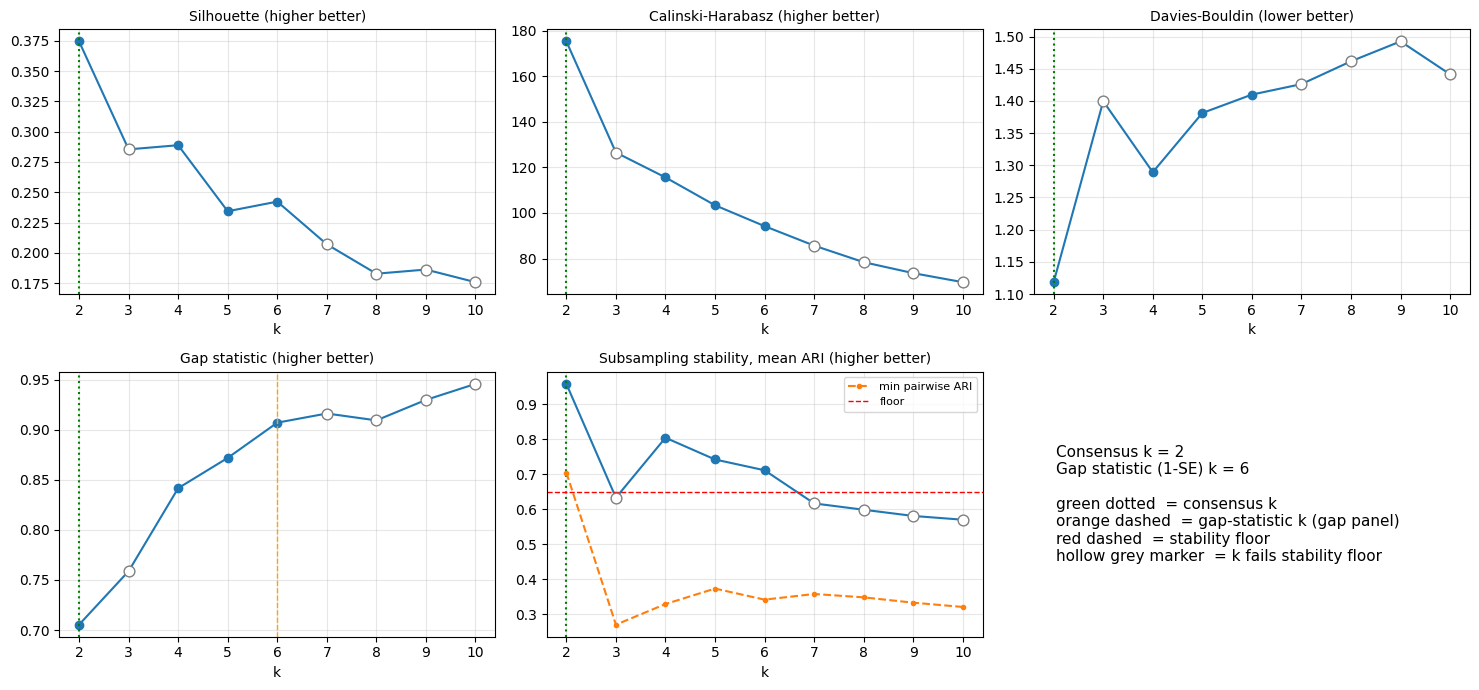

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
specs = [("silhouette", "Silhouette (higher better)"),
         ("calinski", "Calinski-Harabasz (higher better)"),
         ("davies_bouldin", "Davies-Bouldin (lower better)"),
         ("gap", "Gap statistic (higher better)"),
         ("stability", "Subsampling stability, mean ARI (higher better)")]

ks = metrics["k"]
fails = ~(metrics["stability"] >= STABILITY_FLOOR)     # NaN counts as failing
floor_met = bool((~fails).any())

for ax, (col, title) in zip(axes.flat, specs):
    ax.plot(ks, metrics[col], marker="o", color="C0", zorder=2)
    # hollow grey markers = k values that fail the stability floor
    ax.scatter(ks[fails], metrics.loc[fails, col], s=60,
               facecolors="white", edgecolors="grey", zorder=3)
    ax.axvline(consensus_k, color="green", ls=":", lw=1.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("k")
    ax.set_xticks(ks)

    if col == "gap":
        ax.axvline(gap_k, color="orange", ls="--", lw=1)
    if col == "stability":
        ax.plot(ks, metrics["stability_min"], marker=".", ls="--",
                color="C1", label="min pairwise ARI")
        ax.axhline(STABILITY_FLOOR, color="red", ls="--", lw=1, label="floor")
        ax.legend(fontsize=8, loc="best")

info = axes.flat[5]
info.axis("off")
lines = [f"Consensus k = {consensus_k}",
         f"Gap statistic (1-SE) k = {gap_k}",
         ""]
if not floor_met:
    lines += ["WARNING: no k passes the stability floor", ""]
lines += ["green dotted  = consensus k",
          "orange dashed  = gap-statistic k (gap panel)",
          "red dashed  = stability floor",
          "hollow grey marker  = k fails stability floor"]
info.text(0.05, 0.5, "\n".join(lines), transform=info.transAxes,
          fontsize=11, va="center")

plt.tight_layout()
plt.show()

In [11]:
FINAL_K = consensus_k      # override manually if you prefer a different k

assert len(tickers) == X.shape[0], "tickers and X are misaligned"

labels = KMeans(FINAL_K, n_init=10, random_state=RANDOM_STATE).fit_predict(X)
stab, stab_min = subsample_stability(X, FINAL_K)          # renamed
sizes = np.bincount(labels, minlength=FINAL_K)
floor_ok = stab >= STABILITY_FLOOR                        # NaN -> False

print("=" * 46)
print(f"  DATASET     : {FILENAME}")
print(f"  Stocks      : {len(tickers)}")
print(f"  Dimensions  : {X.shape[1]}" + ("  (PCA)" if USE_PCA else "  (raw)"))
print(f"  k           : {FINAL_K}")
print("-" * 46)
print(f"  Silhouette     : {silhouette_score(X, labels):.4f}")
print(f"  Calinski-H     : {calinski_harabasz_score(X, labels):.1f}")
print(f"  Davies-Bouldin : {davies_bouldin_score(X, labels):.4f}")
print(f"  Stability      : {stab:.4f}  (worst pair {stab_min:.3f})")
print(f"  Stability floor: {STABILITY_FLOOR}  ->  {'PASS' if floor_ok else 'FAIL'}")
print("-" * 46)
print(f"  Cluster sizes  : {sizes.tolist()}")
print(f"  Sizes (%)      : {[round(100 * s / len(labels), 1) for s in sizes]}")
print("=" * 46)

# Ticker -> cluster table for downstream use
assignments = pd.DataFrame({"ticker": list(tickers), "cluster": labels})

  DATASET     : ftse250_clustering_ready.csv
  Stocks      : 241
  Dimensions  : 9  (PCA)
  k           : 2
----------------------------------------------
  Silhouette     : 0.3745
  Calinski-H     : 175.2
  Davies-Bouldin : 1.1184
  Stability      : 0.9590  (worst pair 0.705)
  Stability floor: 0.65  ->  PASS
----------------------------------------------
  Cluster sizes  : [130, 111]
  Sizes (%)      : [np.float64(53.9), np.float64(46.1)]


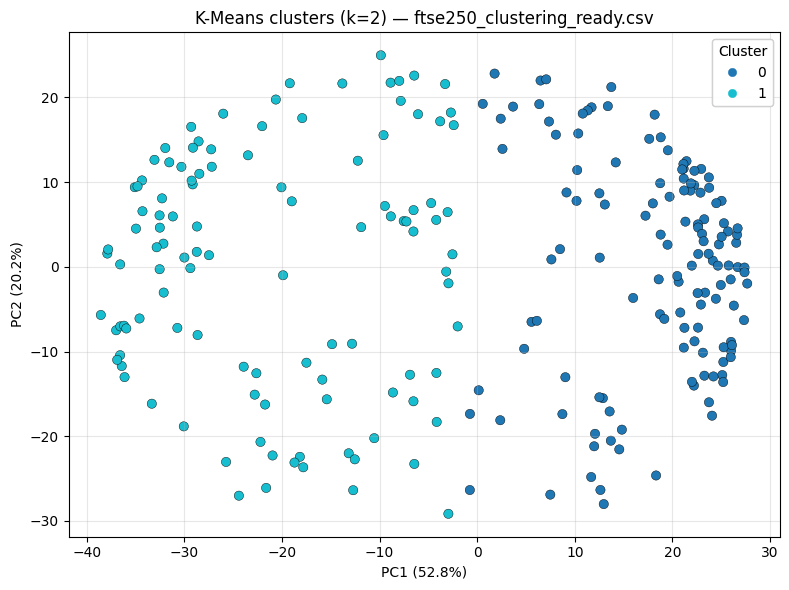

In [12]:

vis = PCA(n_components=2, random_state=RANDOM_STATE).fit(X)
V = vis.transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(V[:, 0], V[:, 1], c=labels, cmap="tab10", s=45, edgecolor="k", linewidth=0.3)
ax.set_title(f"K-Means clusters (k={FINAL_K}) — {FILENAME}")
ax.set_xlabel(f"PC1 ({vis.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({vis.explained_variance_ratio_[1]*100:.1f}%)")
ax.add_artist(ax.legend(*sc.legend_elements(), title="Cluster", loc="best"))
plt.tight_layout(); plt.show()

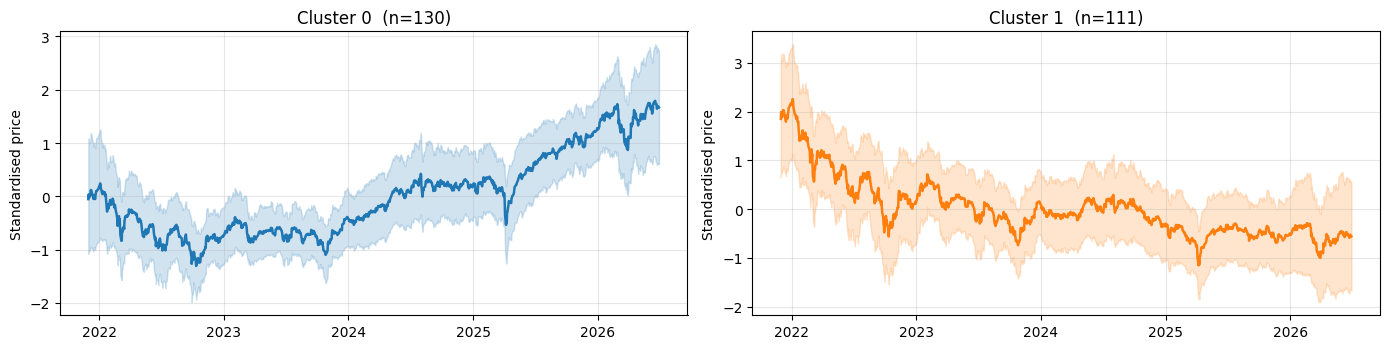

In [13]:

n_cols = 2
n_rows = int(np.ceil(FINAL_K / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), squeeze=False)

for c in range(FINAL_K):
    ax = axes[c // n_cols][c % n_cols]
    mem = A[labels == c]
    mu, sd = mem.mean(axis=0), mem.std(axis=0)
    ax.plot(dates, mu, color=f"C{c}", lw=1.8)
    ax.fill_between(dates, mu - sd, mu + sd, color=f"C{c}", alpha=0.2)
    ax.set_title(f"Cluster {c}  (n={len(mem)})")
    ax.set_ylabel("Standardised price")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for c in range(FINAL_K, n_rows * n_cols):
    axes[c // n_cols][c % n_cols].axis("off")
plt.tight_layout(); plt.show()

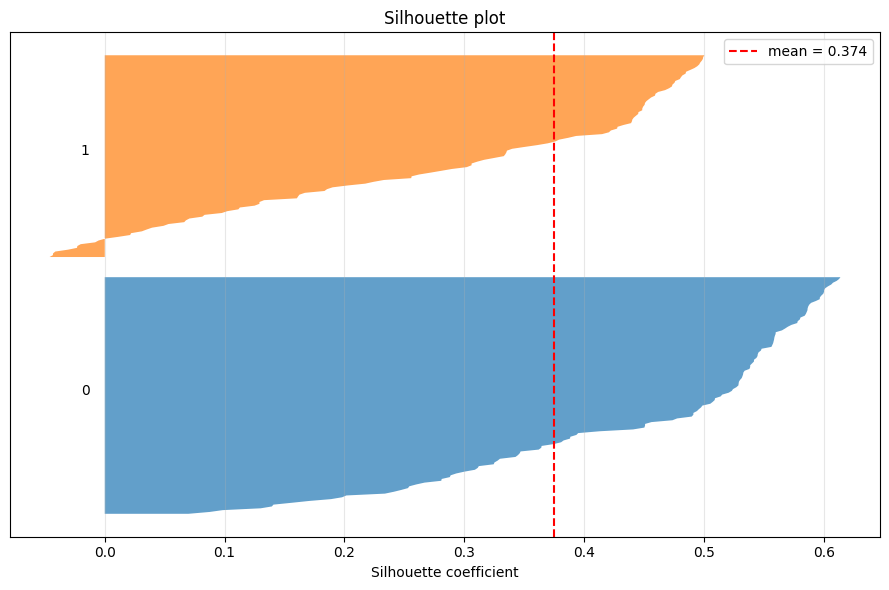

In [14]:

sv = silhouette_samples(X, labels)
fig, ax = plt.subplots(figsize=(9, 6))
y = 10
for c in range(FINAL_K):
    v = np.sort(sv[labels == c])
    ax.fill_betweenx(np.arange(y, y + len(v)), 0, v, facecolor=f"C{c}", alpha=0.7)
    ax.text(-0.02, y + 0.5 * len(v), str(c))
    y += len(v) + 10
ax.axvline(sv.mean(), color="red", ls="--", label=f"mean = {sv.mean():.3f}")
ax.set_title("Silhouette plot"); ax.set_xlabel("Silhouette coefficient")
ax.set_yticks([]); ax.legend(); plt.tight_layout(); plt.show()

In [15]:
import textwrap
for c in range(FINAL_K):
    mem = sorted(tickers[labels == c])
    print(f"Cluster {c} (n={len(mem)}):")
    print(textwrap.fill(", ".join(mem), width=95))
    print()

Cluster 0 (n=130):
3IN.L, AAS.L, AEP.L, AGT.L, AIE.L, AJB.L, ALFA.L, AO.L, ASL.L, ATR.L, ATT.L, ATYM.L, AVON.L,
BAG.L, BBY.L, BCG.L, BGFD.L, BMY.L, BNKR.L, BOWL.L, BPCR.L, BRGE.L, BRWM.L, BUT.L, CHG.L,
CKN.L, CLDN.L, CMCX.L, COA.L, CORD.L, COST.L, CSN.L, CTY.L, CURY.L, CWK.L, DRX.L, EDIN.L,
ELM.L, ESCT.L, EWG.L, EWI.L, FAN.L, FCH.L, FCSS.L, FEML.L, FEV.L, FGP.L, FSG.L, FSV.L, GDWN.L,
GFRD.L, GNC.L, GSCT.L, HANA.L, HGT.L, HILS.L, HMSO.L, HOC.L, HRI.L, HTG.L, HTWS.L, HVPE.L,
HWG.L, IAD.L, ICGT.L, IPF.L, JAM.L, JCH.L, JEDT.L, JEGI.L, JEMI.L, JFJ.L, JGGI.L, JMGI.L,
JSG.L, JTC.L, KIE.L, KLR.L, LRE.L, LWDB.L, MAB.L, MEGP.L, MGNS.L, MNKS.L, MRC.L, MRCH.L, MTO.L,
MTRO.L, MUT.L, MYI.L, OCI.L, OSB.L, PAF.L, PAG.L, PCGH.L, PEY.L, PFD.L, PHI.L, PIN.L, PINT.L,
PLUS.L, PNL.L, POLN.L, PPET.L, PPH.L, QLT.L, QQ.L, RHIM.L, ROR.L, RTW.L, SAGA.L, SAIN.L, SCT.L,
SDP.L, SNR.L, SOI.L, SRP.L, TBCG.L, TCAP.L, TEM.L, TFIF.L, TMPL.L, TRST.L, UEM.L, USA.L,
VEIL.L, VSVS.L, WIX.L, WWH.L, XPS.L

Cluster 1 (n=111):
A

In [16]:
t_idx = np.arange(A.shape[1])
slopes = np.array([np.polyfit(t_idx, row, 1)[0] for row in A])
trend_sign = (slopes > 0).astype(int)

ari_trend = adjusted_rand_score(labels, trend_sign)
print(f"ARI between clusters and sign-of-trend: {ari_trend:.3f}")
print()
if ari_trend > 0.7:
    print("=> The clustering is largely a restatement of trend direction.")
elif ari_trend > 0.3:
    print("=> Trend explains part of the clustering, but not all of it.")
else:
    print("=> The clustering is capturing something beyond trend direction.")

print(f"\nStocks trending up: {trend_sign.sum()} / down: {(1-trend_sign).sum()}")
print("\nMean slope per cluster:")
for c in range(FINAL_K):
    print(f"  Cluster {c}: {slopes[labels == c].mean():+.6f}")

ARI between clusters and sign-of-trend: 0.856

=> The clustering is largely a restatement of trend direction.

Stocks trending up: 139 / down: 102

Mean slope per cluster:
  Cluster 0: +0.001941
  Cluster 1: -0.001442
